In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state
from tensorflow.keras.datasets import mnist, fashion_mnist

import seaborn as sns  # for nicer confusion matrix heatmap

# -------------------
# CONFIG
# -------------------
RANDOM_STATE = 42
USE_SUBSET = False       # True to use smaller stratified subset
SUBSET_SIZE = 5000       # size of training subset
TEST_SIZE = None         # keep default MNIST test set (10k)

# MLP architecture
L1 = 30
L2 = 20
OUTPUT = 10

# t-SNE config
TSNE_PERPLEXITY = 30
TSNE_N_ITER = 1000


In [21]:
def load_mnist_data():
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    X_train = X_train.reshape((X_train.shape[0], -1)).astype(np.float32)
    X_test  = X_test.reshape((X_test.shape[0], -1)).astype(np.float32)
    return X_train, y_train, X_test, y_test

def load_fashion_data():
    (Xf_train, yf_train), (Xf_test, yf_test) = fashion_mnist.load_data()
    Xf_train = Xf_train.reshape((Xf_train.shape[0], -1)).astype(np.float32)
    Xf_test  = Xf_test.reshape((Xf_test.shape[0], -1)).astype(np.float32)
    return Xf_train, yf_train, Xf_test, yf_test

X_train_full, y_train_full, X_test, y_test = load_mnist_data()
Xf_train_full, yf_train_full, Xf_test, yf_test = load_fashion_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
# Optionally subsample training set in a stratified way
if USE_SUBSET:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=SUBSET_SIZE, random_state=RANDOM_STATE)
    idx_train_subset, _ = next(sss.split(X_train_full, y_train_full))
    X_train = X_train_full[idx_train_subset]
    y_train = y_train_full[idx_train_subset]
else:
    X_train, y_train = X_train_full, y_train_full

if TEST_SIZE is not None:
    X_test = X_test[:TEST_SIZE]
    y_test = y_test[:TEST_SIZE]
    Xf_test = Xf_test[:TEST_SIZE]
    yf_test = yf_test[:TEST_SIZE]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
Xf_test_scaled = scaler.transform(Xf_test)


In [23]:
print("Training MLP...")
mlp = MLPClassifier(
    hidden_layer_sizes=(L1, L2),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=128,
    learning_rate_init=1e-3,
    max_iter=200,             # increased for convergence
    early_stopping=True,      # stop when validation score doesn't improve
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
    verbose=True
)
mlp.fit(X_train_scaled, y_train)

print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

print("\nTraining Logistic Regression...")
logr = LogisticRegression(
    solver='saga',
    max_iter=200,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
logr.fit(X_train_scaled, y_train)


Training MLP...
Iteration 1, loss = 0.48206945
Validation score: 0.934167
Iteration 2, loss = 0.18808433
Validation score: 0.946167
Iteration 3, loss = 0.14326442
Validation score: 0.948833
Iteration 4, loss = 0.11954850
Validation score: 0.950667
Iteration 5, loss = 0.10353204
Validation score: 0.954667
Iteration 6, loss = 0.09137488
Validation score: 0.956833
Iteration 7, loss = 0.08112166
Validation score: 0.956667
Iteration 8, loss = 0.07359829
Validation score: 0.954333
Iteration 9, loss = 0.06707129
Validation score: 0.958333
Iteration 10, loss = 0.06108152
Validation score: 0.958167
Iteration 11, loss = 0.05489150
Validation score: 0.957167
Iteration 12, loss = 0.04972667
Validation score: 0.956667
Iteration 13, loss = 0.04668835
Validation score: 0.955500
Iteration 14, loss = 0.04340248
Validation score: 0.956667
Iteration 15, loss = 0.03986058
Validation score: 0.954333
Iteration 16, loss = 0.03658526
Validation score: 0.954333
Iteration 17, loss = 0.03476690
Validation score:

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=200, n_jobs=-1, random_state=42, solver='saga')

In [24]:
def eval_model(model, Xs, ys, model_name="model"):
    ypred = model.predict(Xs)
    acc = accuracy_score(ys, ypred)
    f1 = f1_score(ys, ypred, average='macro')
    cm = confusion_matrix(ys, ypred)
    return {'name': model_name, 'accuracy': acc, 'f1_macro': f1, 'y_pred': ypred, 'confusion_matrix': cm}

res_mlp = eval_model(mlp, X_test_scaled, y_test, "MLP(30-20)")
res_rf  = eval_model(rf, X_test_scaled, y_test, "RandomForest")
res_lr  = eval_model(logr, X_test_scaled, y_test, "LogisticRegression")

# Print metrics
for r in [res_mlp, res_rf, res_lr]:
    print(f"\n=== {r['name']} ===")
    print(f"Accuracy: {r['accuracy']:.4f}")
    print(f"F1 (macro): {r['f1_macro']:.4f}")
    print("Classification report:")
    print(classification_report(y_test, r['y_pred'], digits=4))



=== MLP(30-20) ===
Accuracy: 0.9624
F1 (macro): 0.9620
Classification report:
              precision    recall  f1-score   support

           0     0.9709    0.9878    0.9793       980
           1     0.9858    0.9806    0.9832      1135
           2     0.9548    0.9622    0.9585      1032
           3     0.9615    0.9634    0.9624      1010
           4     0.9625    0.9674    0.9650       982
           5     0.9609    0.9372    0.9489       892
           6     0.9677    0.9708    0.9693       958
           7     0.9649    0.9621    0.9635      1028
           8     0.9358    0.9435    0.9397       974
           9     0.9559    0.9445    0.9501      1009

    accuracy                         0.9624     10000
   macro avg     0.9621    0.9619    0.9620     10000
weighted avg     0.9624    0.9624    0.9624     10000


=== RandomForest ===
Accuracy: 0.9708
F1 (macro): 0.9706
Classification report:
              precision    recall  f1-score   support

           0     0.9710   

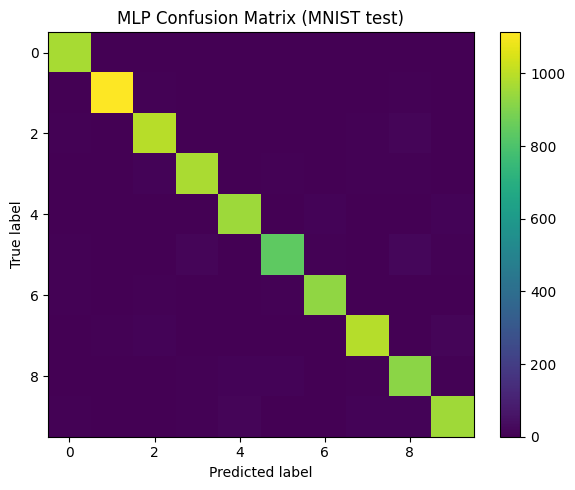

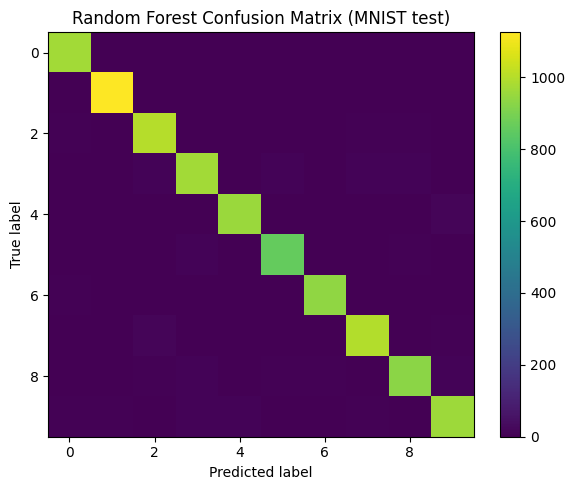

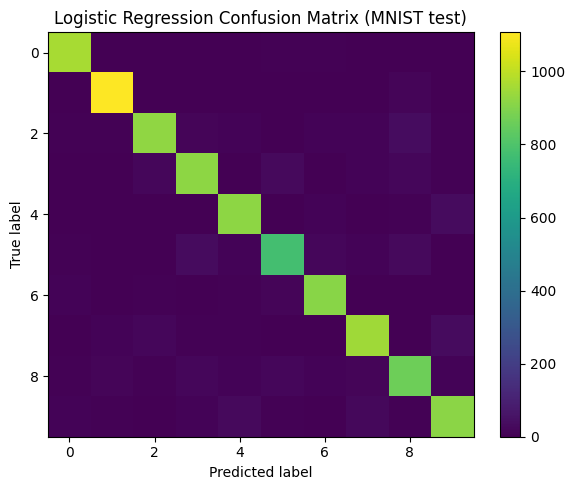

In [25]:
def plot_confusion(cm, title="Confusion matrix"):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest', aspect='auto')
    plt.title(title)
    plt.colorbar()
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

plot_confusion(res_mlp['confusion_matrix'], "MLP Confusion Matrix (MNIST test)")
plot_confusion(res_rf['confusion_matrix'], "Random Forest Confusion Matrix (MNIST test)")
plot_confusion(res_lr['confusion_matrix'], "Logistic Regression Confusion Matrix (MNIST test)")


In [26]:
def forward_activations(X, coefs, intercepts, activation='relu'):
    a = X
    activations = []
    for i, (W, b) in enumerate(zip(coefs, intercepts)):
        z = a.dot(W) + b
        if i < len(coefs) - 1:
            if activation == 'relu':
                a = np.maximum(z, 0)
            elif activation == 'tanh':
                a = np.tanh(z)
            elif activation == 'logistic':
                a = 1/(1+np.exp(-z))
            activations.append(a)
        else:
            a = z
    return activations

trained_coefs = mlp.coefs_
trained_intercepts = mlp.intercepts_
trained_hidden_activations = forward_activations(X_test_scaled, trained_coefs, trained_intercepts, activation='relu')
act20_trained = trained_hidden_activations[1]

# Untrained network
rng = check_random_state(RANDOM_STATE)
untrained_coefs = [rng.normal(scale=0.1, size=W.shape) for W in trained_coefs]
untrained_intercepts = [rng.normal(scale=0.1, size=b.shape) for b in trained_intercepts]
untrained_hidden_activations = forward_activations(X_test_scaled, untrained_coefs, untrained_intercepts, activation='relu')
act20_untrained = untrained_hidden_activations[1]


Running t-SNE for: t-SNE of 20-neuron layer (MLP trained) on MNIST test


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


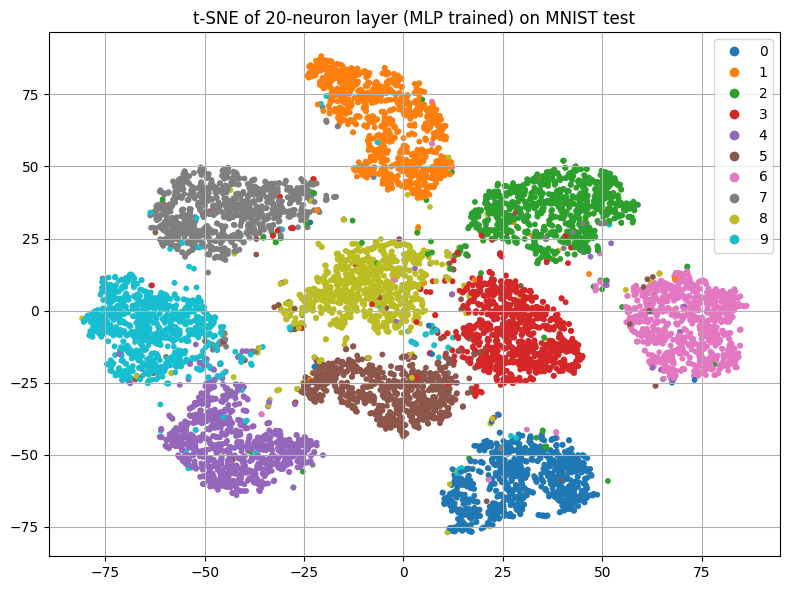

Running t-SNE for: t-SNE of 20-neuron layer (MLP untrained) on MNIST test


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


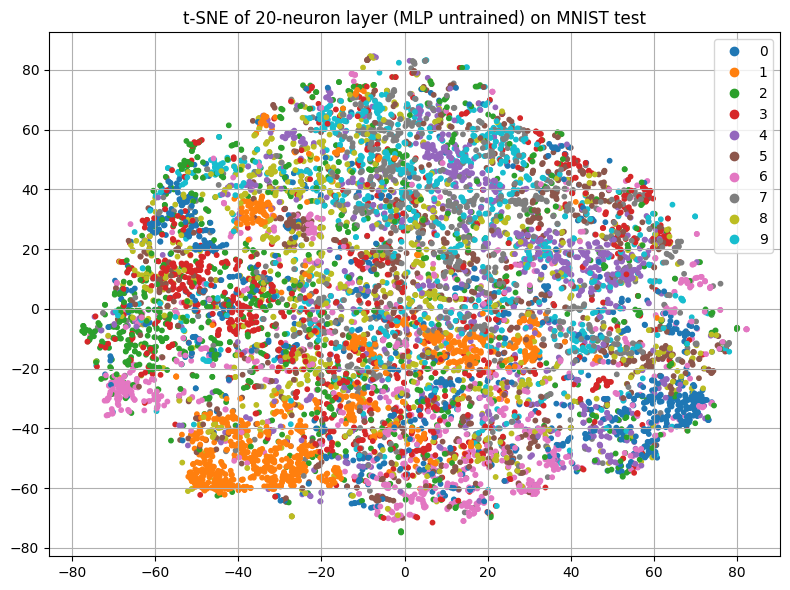

In [27]:
def plot_tsne(X_embed, y, title="t-SNE visualization"):
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_embed[:,0], X_embed[:,1], c=y, cmap='tab10', s=10)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(range(10)))
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def run_tsne(X, y, title="t-SNE"):
    print(f"Running t-SNE for: {title}")
    tsne = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_N_ITER, random_state=RANDOM_STATE)
    X_embed = tsne.fit_transform(X)
    plot_tsne(X_embed, y, title)
    return X_embed

embed20_trained = run_tsne(act20_trained, y_test, "t-SNE of 20-neuron layer (MLP trained) on MNIST test")
embed20_untrained = run_tsne(act20_untrained, y_test, "t-SNE of 20-neuron layer (MLP untrained) on MNIST test")


In [28]:
# Test MLP on Fashion-MNIST
res_mlp_fashion = eval_model(mlp, Xf_test_scaled, yf_test, "MLP(30-20) on Fashion-MNIST")

# Get activations for Fashion-MNIST
fashion_hidden_activations = forward_activations(Xf_test_scaled, trained_coefs, trained_intercepts, activation='relu')
act20_fashion = fashion_hidden_activations[1]


In [29]:
# Print metrics for Fashion-MNIST
print(f"\n=== {res_mlp_fashion['name']} ===")
print(f"Accuracy: {res_mlp_fashion['accuracy']:.4f}")
print(f"F1 (macro): {res_mlp_fashion['f1_macro']:.4f}")
print("Classification report:")
print(classification_report(yf_test, res_mlp_fashion['y_pred'], digits=4))



=== MLP(30-20) on Fashion-MNIST ===
Accuracy: 0.1243
F1 (macro): 0.0759
Classification report:
              precision    recall  f1-score   support

           0     0.0645    0.0020    0.0039      1000
           1     0.0014    0.0010    0.0012      1000
           2     0.1179    0.6470    0.1994      1000
           3     0.1486    0.1990    0.1702      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.1140    0.1170    0.1155      1000
           6     0.2264    0.0240    0.0434      1000
           7     0.1987    0.2510    0.2218      1000
           8     0.2857    0.0020    0.0040      1000
           9     0.0000    0.0000    0.0000      1000

    accuracy                         0.1243     10000
   macro avg     0.1157    0.1243    0.0759     10000
weighted avg     0.1157    0.1243    0.0759     10000



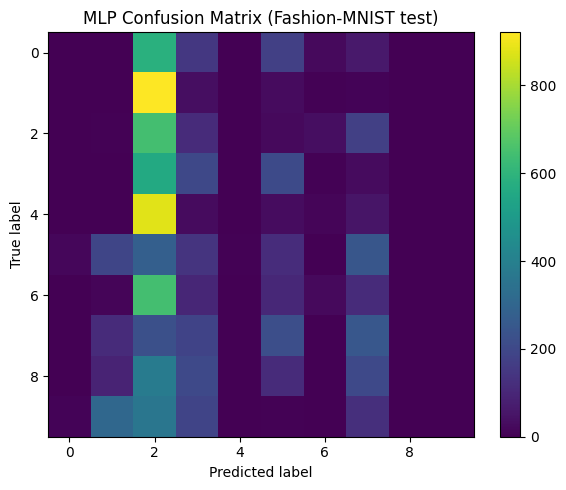

Running t-SNE for: t-SNE of 20-neuron layer (MLP trained) on Fashion-MNIST test


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


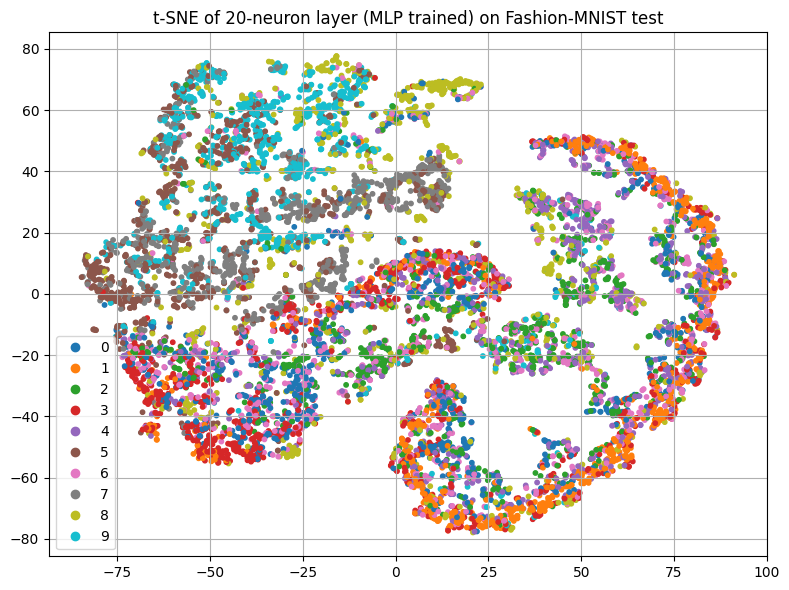

In [30]:
plot_confusion(res_mlp_fashion['confusion_matrix'], "MLP Confusion Matrix (Fashion-MNIST test)")
embed20_fashion = run_tsne(act20_fashion, yf_test, "t-SNE of 20-neuron layer (MLP trained) on Fashion-MNIST test")


# 3.2 Using CNN

In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import time
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
BATCH_SIZE = 128
EPOCHS = 5 # small for quick demo
NUM_CLASSES = 10


In [32]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape to (samples, height, width, channels)
X_train = X_train.reshape(-1,28,28,1).astype('float32') / 255.0
X_test = X_test.reshape(-1,28,28,1).astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)


In [33]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

# Train
start_time = time.time()
cnn_model.fit(X_train, y_train_cat, validation_split=0.1, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
cnn_train_time = time.time() - start_time


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 - 10s - 24ms/step - accuracy: 0.9312 - loss: 0.2415 - val_accuracy: 0.9750 - val_loss: 0.0900
Epoch 2/5
422/422 - 9s - 22ms/step - accuracy: 0.9787 - loss: 0.0725 - val_accuracy: 0.9845 - val_loss: 0.0572
Epoch 3/5
422/422 - 9s - 22ms/step - accuracy: 0.9859 - loss: 0.0483 - val_accuracy: 0.9873 - val_loss: 0.0488
Epoch 4/5
422/422 - 9s - 22ms/step - accuracy: 0.9888 - loss: 0.0361 - val_accuracy: 0.9882 - val_loss: 0.0455
Epoch 5/5
422/422 - 9s - 22ms/step - accuracy: 0.9924 - loss: 0.0266 - val_accuracy: 0.9868 - val_loss: 0.0520


In [34]:
start_inf = time.time()
y_pred_probs = cnn_model.predict(X_test)
cnn_inference_time = time.time() - start_inf

y_pred = np.argmax(y_pred_probs, axis=1)

cnn_acc = accuracy_score(y_test, y_pred)
cnn_f1 = f1_score(y_test, y_pred, average='macro')
cnn_cm = confusion_matrix(y_test, y_pred)

print("Simple CNN Results:")
print(f"Accuracy: {cnn_acc:.4f}, F1 (macro): {cnn_f1:.4f}")
print(classification_report(y_test, y_pred, digits=4))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Simple CNN Results:
Accuracy: 0.9864, F1 (macro): 0.9863
              precision    recall  f1-score   support

           0     0.9858    0.9949    0.9904       980
           1     0.9921    0.9965    0.9943      1135
           2     0.9912    0.9797    0.9854      1032
           3     0.9901    0.9901    0.9901      1010
           4     0.9722    0.9990    0.9854       982
           5     0.9898    0.9832    0.9865       892
           6     0.9885    0.9864    0.9875       958
           7     0.9844    0.9805    0.9825      1028
           8     0.9845    0.9784    0.9815       974
           9     0.9850    0.9742    0.9796      1009

    accuracy                         0.9864     10000
   macro avg     0.9864    0.9863    0.9863     10000
weighted avg     0.9864    0.9864    0.9864     10000



Simple CNN Confusion Matrix (MNIST test)


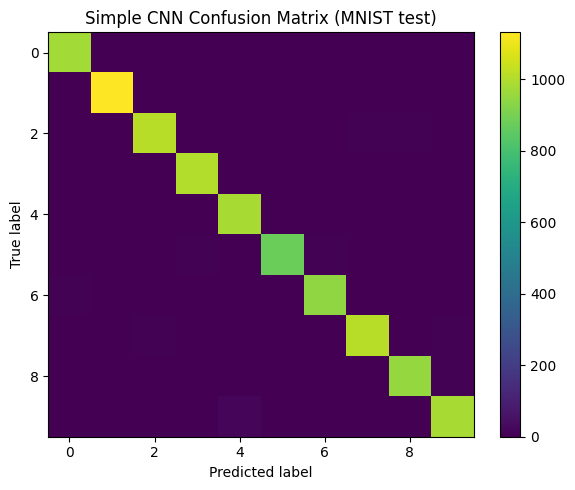

In [35]:
print("Simple CNN Confusion Matrix (MNIST test)")
plot_confusion(cnn_cm, "Simple CNN Confusion Matrix (MNIST test)")


In [36]:
!pip install tensorflow

In [37]:
# Preprocessing for pretrained models
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

# Load data again, keep shape
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = mnist.load_data()

# Convert grayscale (1 channel) to 3 channels by repeating
X_test_rgb = np.repeat(X_test_orig[..., np.newaxis], 3, -1)

# Resize to 224x224 (required by default for MobileNetV2 and EfficientNetB0)
print("Resizing images to 224x224...")
X_test_resized = np.array([img_to_array(array_to_img(im, scale=False).resize((224,224))) for im in X_test_rgb])

print("Resized shape:", X_test_resized.shape)

Resizing images to 224x224...
Resized shape: (10000, 224, 224, 3)


In [38]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficientnet

# Preprocess for MobileNetV2
X_test_mobilenet = preprocess_mobilenet(X_test_resized.copy())

# Preprocess for EfficientNetB0
X_test_efficientnet = preprocess_efficientnet(X_test_resized.copy())

# Load models (weights='imagenet' is default)
mobilenet_model = MobileNetV2(weights='imagenet', include_top=True)
print("MobileNetV2 params:", mobilenet_model.count_params())

efficientnet_model = EfficientNetB0(weights='imagenet', include_top=True)
print("EfficientNetB0 params:", efficientnet_model.count_params())


MobileNetV2 params: 3538984
EfficientNetB0 params: 5330571


In [39]:
import time

# MobileNet
print("Evaluating MobileNetV2...")
start_time = time.time()
y_pred_mobilenet_probs = mobilenet_model.predict(X_test_mobilenet, batch_size=32)
mobilenet_inference_time = time.time() - start_time
y_pred_mobilenet = np.argmax(y_pred_mobilenet_probs, axis=1)

# Evaluate MobileNetV2
# Use y_test_orig (loaded in Cell 19)
mobilenet_acc = accuracy_score(y_test_orig, y_pred_mobilenet)
mobilenet_f1 = f1_score(y_test_orig, y_pred_mobilenet, average='macro')
mobilenet_cm = confusion_matrix(y_test_orig, y_pred_mobilenet)
print("MobileNetV2 Results:")
print(f"Accuracy: {mobilenet_acc:.4f}, F1 (macro): {mobilenet_f1:.4f}")
print(classification_report(y_test_orig, y_pred_mobilenet, digits=4))


# EfficientNet
print("\nEvaluating EfficientNetB0...")
start_time = time.time()
y_pred_efficientnet_probs = efficientnet_model.predict(X_test_efficientnet, batch_size=32)
efficientnet_inference_time = time.time() - start_time
y_pred_efficientnet = np.argmax(y_pred_efficientnet_probs, axis=1)

# Evaluate EfficientNetB0
# Use y_test_orig (loaded in Cell 19)
efficientnet_acc = accuracy_score(y_test_orig, y_pred_efficientnet)
efficientnet_f1 = f1_score(y_test_orig, y_pred_efficientnet, average='macro')
efficientnet_cm = confusion_matrix(y_test_orig, y_pred_efficientnet)
print("EfficientNetB0 Results:")
print(f"Accuracy: {efficientnet_acc:.4f}, F1 (macro): {efficientnet_f1:.4f}")
print(classification_report(y_test_orig, y_pred_efficientnet, digits=4))

Evaluating MobileNetV2...
313/313 ━━━━━━━━━━━━━━━━━━━━ 173s 549ms/step
MobileNetV2 Results:
Accuracy: 0.0001, F1 (macro): 0.0000
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       980
           1     0.0000    0.0000    0.0000      1135
           2     0.0000    0.0000    0.0000      1032
           3     0.0000    0.0000    0.0000      1010
           4     1.0000    0.0010    0.0020       982
           5     0.0000    0.0000    0.0000       892
           6     0.0000    0.0000    0.0000       958
           7     0.0000    0.0000    0.0000      1028
           8     0.0000    0.0000    0.0000       974
           9     0.0000    0.0000    0.0000      1009
         110     0.0000    0.0000    0.0000         0
         111     0.0000    0.0000    0.0000         0
         188     0.0000    0.0000    0.0000         0
         190     0.0000    0.0000    0.0000         0
         251     0.0000    0.0000    0.0000         0
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

313/313 ━━━━━━━━━━━━━━━━━━━━ 304s 969ms/step
EfficientNetB0 Results:
Accuracy: 0.0000, F1 (macro): 0.0000
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     980.0
           1     0.0000    0.0000    0.0000    1135.0
           2     0.0000    0.0000    0.0000    1032.0
           3     0.0000    0.0000    0.0000    1010.0
           4     0.0000    0.0000    0.0000     982.0
           5     0.0000    0.0000    0.0000     892.0
           6     0.0000    0.0000    0.0000     958.0
           7     0.0000    0.0000    0.0000    1028.0
           8     0.0000    0.0000    0.0000     974.0
           9     0.0000    0.0000    0.0000    1009.0
         111     0.0000    0.0000    0.0000       0.0
         190     0.0000    0.0000    0.0000       0.0
         327     0.0000    0.0000    0.0000       0.0
         362     0.0000    0.0000    0.0000       0.0
         409     0.0000    0.0000    0.0000       0.0
         413     0.0000    0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [40]:
summary = {
    'Model': ['Simple CNN', 'MobileNetV2 (pretrained)', 'EfficientNetB0 (pretrained)'],
    'Accuracy': [cnn_acc, mobilenet_acc, efficientnet_acc],
    'F1_macro': [cnn_f1, mobilenet_f1, efficientnet_f1],
    'Parameters': [cnn_model.count_params(), mobilenet_model.count_params(), efficientnet_model.count_params()],
    'Inference_time_sec': [cnn_inference_time, mobilenet_inference_time, efficientnet_inference_time]
}

import pandas as pd
df_summary = pd.DataFrame(summary)
print("\n=== Model Comparison Summary ===")
print(df_summary)


=== Model Comparison Summary ===
                         Model  Accuracy  F1_macro  Parameters  \
0                   Simple CNN    0.9864  0.986300      693962   
1     MobileNetV2 (pretrained)    0.0001  0.000024     3538984   
2  EfficientNetB0 (pretrained)    0.0000  0.000000     5330571   

   Inference_time_sec  
0             0.67749  
1           177.63655  
2           309.74473  



MobileNetV2 Confusion Matrix (MNIST test)


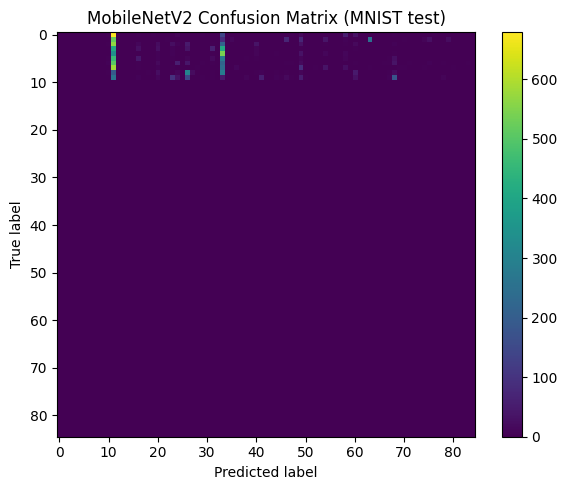


EfficientNetB0 Confusion Matrix (MNIST test)


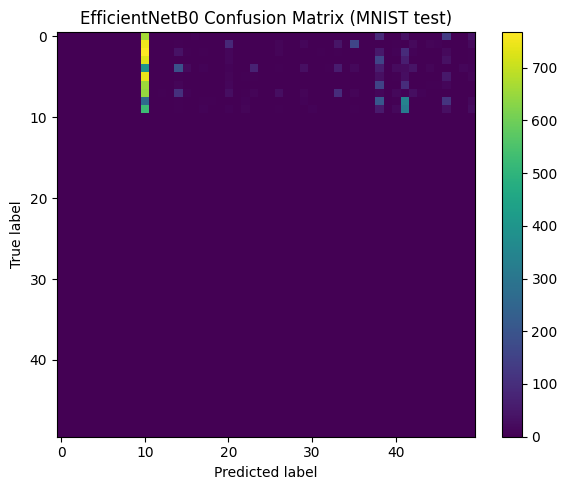

In [41]:
print("\nMobileNetV2 Confusion Matrix (MNIST test)")
plot_confusion(mobilenet_cm, "MobileNetV2 Confusion Matrix (MNIST test)")
print("\nEfficientNetB0 Confusion Matrix (MNIST test)")
plot_confusion(efficientnet_cm, "EfficientNetB0 Confusion Matrix (MNIST test)")